In [3]:
import tkinter as tk
from tkinter import filedialog, ttk
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

In [11]:
class DataAnalysisApp:
    def __init__(self, root):
        self.root = root
        self.root.title("FCS FITTING APP")
        self.root.geometry("1200x800")
        
        # Internal State
        self.loaded_files = []
        
        self.setup_ui()

    def setup_ui(self):
        # --- Main Layout Containers ---
        self.sidebar = tk.Frame(self.root, width=250, bg="#f0f0f0", relief="sunken", borderwidth=1)
        self.sidebar.pack(side="left", fill="y")
        
        self.main_content = tk.Frame(self.root, bg="white")
        self.main_content.pack(side="right", expand=True, fill="both")

        # --- Sidebar Components ---
        tk.Label(self.sidebar, text="File Explorer", font=("Arial", 12, "bold"), bg="#f0f0f0").pack(pady=10)
        
        btn_frame = tk.Frame(self.sidebar, bg="#f0f0f0")
        btn_frame.pack(fill="x", padx=5)
        
        tk.Button(btn_frame, text="Load Files", command=self.load_files).pack(side="left", expand=True, fill="x")
        tk.Button(btn_frame, text="Load Folder", command=self.load_folder).pack(side="left", expand=True, fill="x")

        self.file_listbox = tk.Listbox(self.sidebar, selectmode="single")
        self.file_listbox.pack(expand=True, fill="both", padx=5, pady=5)
        self.file_listbox.bind("<<ListboxSelect>>", self.on_file_select)

        # --- Top Control Bar (Fitting Options) ---
        self.controls = tk.Frame(self.main_content, height=100, relief="raised", borderwidth=1)
        self.controls.pack(side="top", fill="x")

        tk.Label(self.controls, text="Fitting Style:").grid(row=0, column=0, padx=5, pady=10)
        self.fit_style = ttk.Combobox(self.controls, values=["Linear", "Exponential", "Gaussian", "Diffusion"])
        self.fit_style.set("Choose Style")
        self.fit_style.grid(row=0, column=1, padx=5)

        tk.Label(self.controls, text="Parameters:").grid(row=0, column=2, padx=5)
        self.param_entry = tk.Entry(self.controls)
        self.param_entry.insert(0, "p1=1.0, p2=0.5")
        self.param_entry.grid(row=0, column=3, padx=5)

        tk.Button(self.controls, text="Update Fit", command=self.update_graphs, bg="#e1e1e1").grid(row=0, column=4, padx=10)

        # --- Graphing Area (2x2 Grid) ---
        self.fig, self.axs = plt.subplots(2, 2, figsize=(8, 6), constrained_layout=True)
        self.canvas = FigureCanvasTkAgg(self.fig, master=self.main_content)
        self.canvas.get_tk_widget().pack(expand=True, fill="both")
        
        # Initialize subplots
        self.axs[0, 0].set_title("Autocorrelation")
        self.axs[0, 1].set_title("Intensity Trace")
        self.axs[1, 0].set_title("Residuals")
        self.axs[1, 1].set_title("Fitting Curve")

    def load_files(self):
        files = filedialog.askopenfilenames(
            filetypes=[("Data files", "*.dat *.czi *.ptu"), ("All files", "*.*")]
        )
        if files:
            for f in files:
                if f not in self.loaded_files:
                    self.loaded_files.append(f)
                    self.file_listbox.insert(tk.END, f.split("/")[-1])

    def load_folder(self):
        folder = filedialog.askdirectory()
        if folder:
            import os
            extensions = ('.dat', '.czi', '.ptu')
            for root, dirs, files in os.walk(folder):
                for file in files:
                    if file.endswith(extensions):
                        full_path = os.path.join(root, file)
                        if full_path not in self.loaded_files:
                            self.loaded_files.append(full_path)
                            self.file_listbox.insert(tk.END, file)

    def on_file_select(self, event):
        selection = event.widget.curselection()
        if selection:
            index = selection[0]
            selected_file = self.loaded_files[index]
            print(f"Loading: {selected_file}")
            self.update_graphs()

    def update_graphs(self):
        # Clear and redraw (Placeholder logic)
        for ax in self.axs.flat:
            ax.clear()
        
        self.axs[0, 0].set_title("Autocorrelation")
        self.axs[0, 1].set_title("Intensity Trace")
        self.axs[1, 0].set_title("Residuals")
        self.axs[1, 1].set_title(f"Fit: {self.fit_style.get()}")

        # Placeholder plot
        self.axs[0, 0].plot([1, 2, 3], [4, 1, 2]) 
        
        self.canvas.draw()
    

Loading: C:/Users/hanni/Downloads/dat-20260505T073325Z-3-001\dat\atto5651nM_purewater.dat
Loading: C:/Users/hanni/Downloads/dat-20260505T073325Z-3-001\dat\atto5651nM_5CP.dat
Loading: C:/Users/hanni/Downloads/dat-20260505T073325Z-3-001\dat\atto5651nM_1CP.dat
Loading: C:/Users/hanni/Downloads/dat-20260505T073325Z-3-001\dat\atto5651nM_10CP.dat
Loading: C:/Users/hanni/Downloads/dat-20260505T073325Z-3-001\dat\atto5651nM_5CP.dat
Loading: C:/Users/hanni/Downloads/dat-20260505T073325Z-3-001\dat\atto5651nM_1CP.dat
Loading: C:/Users/hanni/Downloads/dat-20260505T073325Z-3-001\dat\atto5651nM_10CP.dat


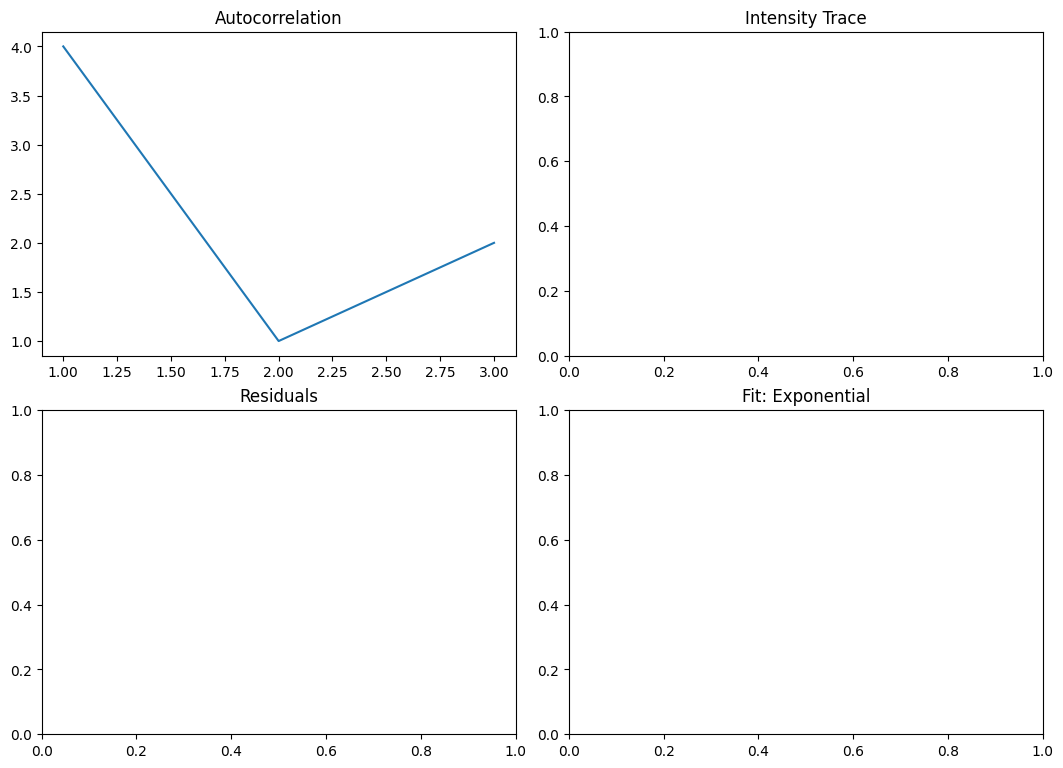

In [13]:
root = tk.Tk()
app = DataAnalysisApp(root)
root.mainloop()